# 03 – Latent Space Analysis

In [1]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import os
from astropy.io import fits
from astropy.timeseries import LombScargle
from astropy.visualization import ImageNormalize, LogStretch, PercentileInterval
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
import umap
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-14 17:42:57.235206: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-14 17:42:57.356825: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744645377.401892    7204 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744645377.424730    7204 cuda_blas.cc

## Load Latent Encodings and File Paths

In [2]:
latent = np.load("../outputs/latent/latent_vectors_order30.npy")
print("Latent shape:", latent.shape)

fits_root = "../../aumicAE1"

with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

print(f"Loaded {len(vis_a_files)} resolved FITS file paths.")

Latent shape: (95, 8)
Loaded 95 resolved FITS file paths.


## Extract Observation Timestamps

Each FITS file encodes the observation timestamp in its filename. I extract this information to align it with each latent vector.

In [3]:
def extract_datetime_from_filename(path):
    fname = os.path.basename(path)
    date_str = fname.split("-")[1].replace("T", "")
    return datetime.strptime(date_str, "%Y%m%d%Hh%Mm%Ss")

timestamps = [extract_datetime_from_filename(f) for f in vis_a_files]
timestamps = pd.to_datetime(timestamps)

## **PART A**

In the first part of this notebook, I analyze the 8-dimensional latent representations produced by the autoencoder trained on spectral order 30. The goal is to explore how these latent encodings evolve over time and whether they encode astrophysical variability such as stellar activity.

## Goals

- Align latent vectors with observation timestamps
- Visualize temporal evolution of the latent space
- Apply PCA for comparison and dimensionality insights

Sort both timestamps and latent vectors chronologically:

In [4]:
timestamps, latent = zip(*sorted(zip(timestamps, latent)))
timestamps = pd.to_datetime(timestamps)
latent = np.array(latent)

print(f"Aligned {len(timestamps)} timestamps to latent vectors.")

Aligned 95 timestamps to latent vectors.


## Visualize Latent Dimensions Over Time

This plot helps reveal whether the latent space captures temporal variability — possibly due to rotational modulation or magnetic activity on AU Mic.

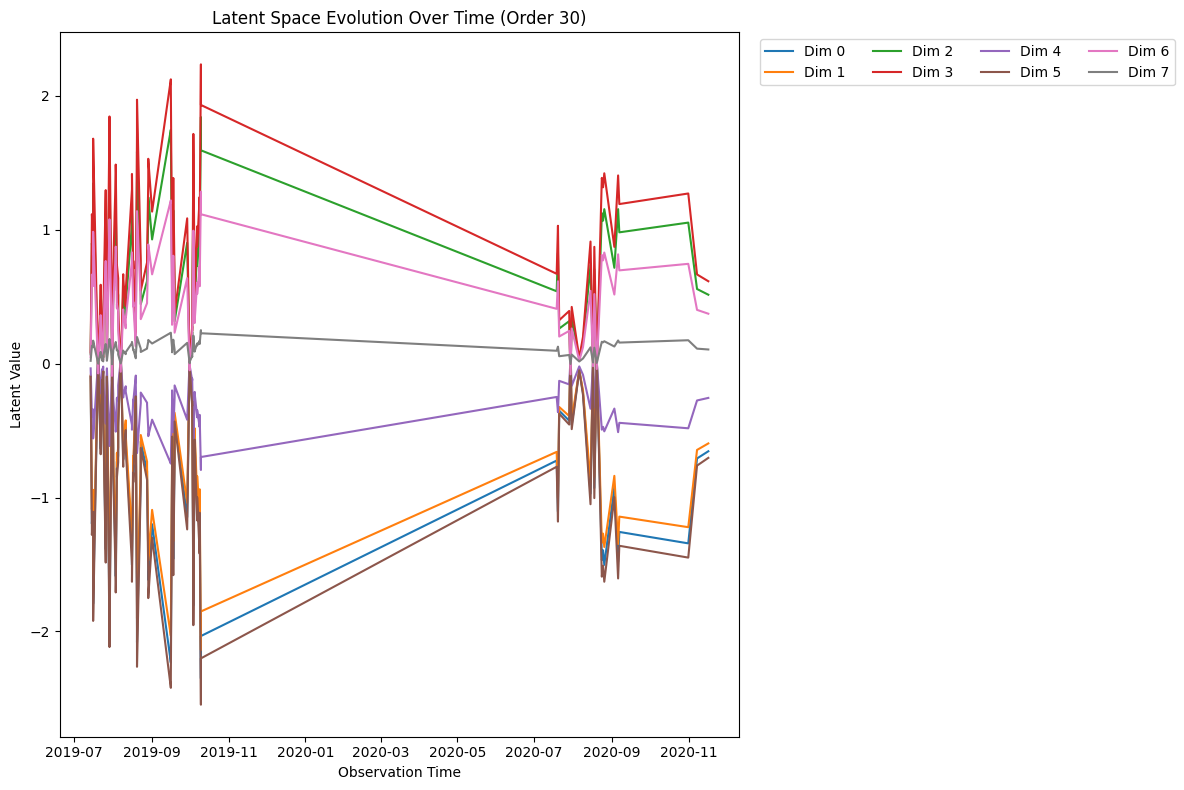

In [5]:
plt.figure(figsize=(12, 8))
for i in range(latent.shape[1]):
    plt.plot(timestamps, latent[:, i], label=f"Dim {i}")
plt.xlabel("Observation Time")
plt.ylabel("Latent Value")
plt.title("Latent Space Evolution Over Time (Order 30)")
plt.legend(ncol=4, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

os.makedirs("../outputs/plots", exist_ok=True)
plt.savefig("../outputs/plots/latent_over_time_order30.png", dpi=150)
plt.show()

This plot confirms that the autoencoder isn't just memorizing spectra, but actually learns compact features that vary over time, possibly encoding stellar surface variability. It's a green light to:

- Correlate latent dimensions with known activity indicators (e.g., Hα, Ca II triplet).

- Compare with PCA to see which structures are uniquely learned by the autoencoder.

- Investigate if some latent dimensions cycle periodically — a hint of stellar rotation.

## Principal Component Analysis (PCA) on Order 30

To interpret what structure the autoencoder has learned, I now apply PCA to the same normalized spectra that were used to train the model. This gives a linear baseline for comparison.

In [6]:
X = np.load("../outputs/preprocessed/X_order30.npy") 
print("Spectra shape:", X.shape)

Spectra shape: (95, 4096, 1)


I squeeze out the last dimension to be able to apply PCA:

In [7]:
X_flat = X.squeeze()  # Result: shape (101, 4096)

In [8]:
pca = PCA(n_components=8)
Z_pca = pca.fit_transform(X_flat)

print("PCA-transformed shape:", Z_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

PCA-transformed shape: (95, 8)
Explained variance ratio: [9.67526078e-01 1.75459068e-02 8.51551350e-03 2.44801003e-03
 1.75151404e-03 1.12479005e-03 2.09286300e-04 1.09254775e-04]


### Explained Variance by PCA

I now plot the explained variance ratio per component to see how many are needed to describe the data.

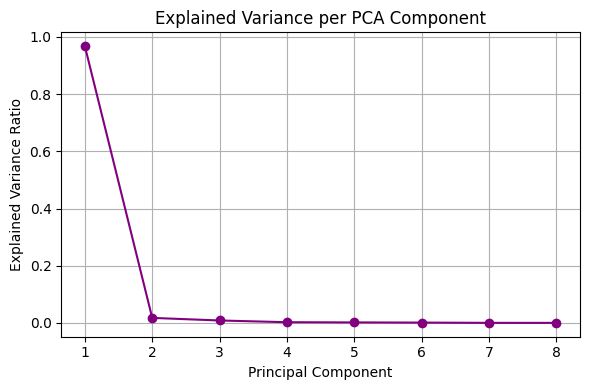

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, 9), pca.explained_variance_ratio_, 'o-', color='purple')
plt.title("Explained Variance per PCA Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/plots/pca_variance_order30.png", dpi=150)
plt.show()

We can see that the first component explains almost all the variance, this is already a hint that PCA likely fails to capture the stellar structure.

## PCA Components Over Time

Now I visualize the 8 PCA components over time to compare them with the autoencoder's latent space evolution.

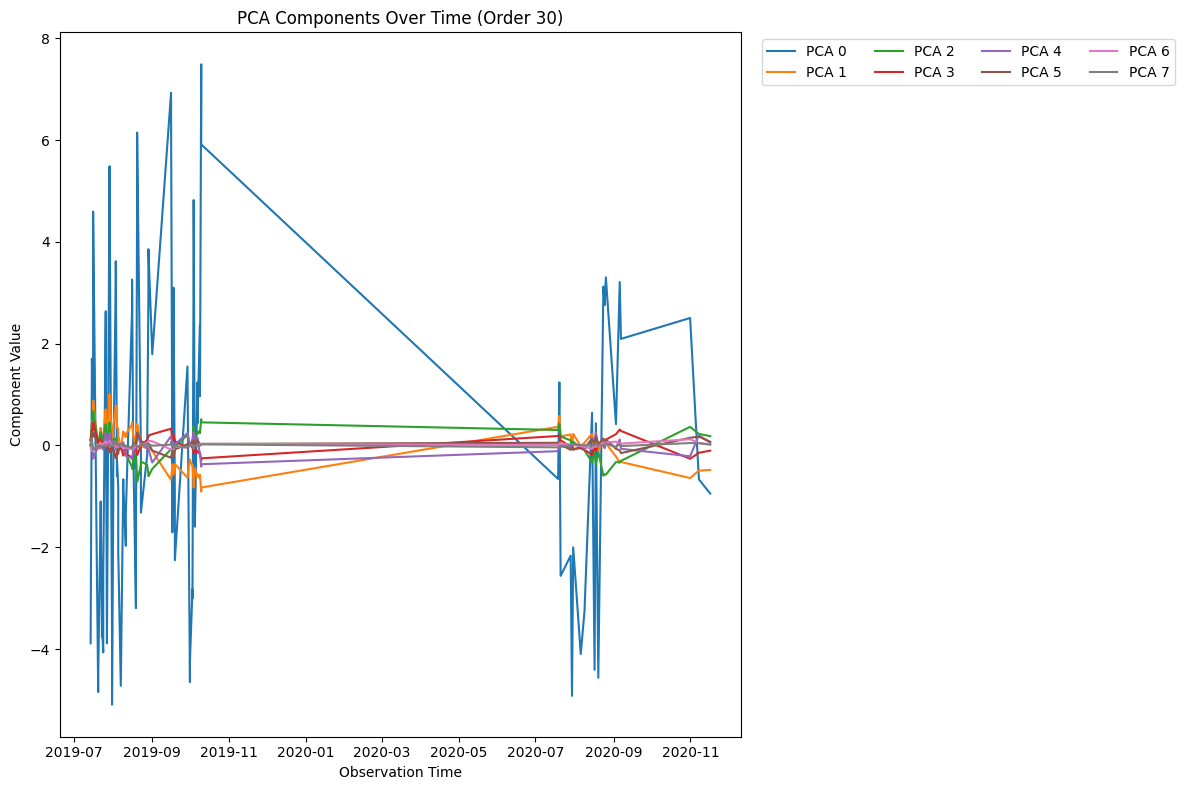

In [10]:
plt.figure(figsize=(12, 8))
for i in range(Z_pca.shape[1]):
    plt.plot(timestamps, Z_pca[:, i], label=f"PCA {i}")
plt.xlabel("Observation Time")
plt.ylabel("Component Value")
plt.title("PCA Components Over Time (Order 30)")
plt.legend(ncol=4, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../outputs/plots/pca_over_time_order30.png", dpi=150)
plt.show()

Here we also see way less varaibility then for the latent space vector.

## **PART B**

In this Part I analyze the latent representations from autoencoders trained on spectral orders 25, 46, and 47 — where key stellar activity indicators such as Hα (order 25) and the Ca II infrared triplet (order 46 and 47) reside.

## Goals

- Correlate latent vectors with physical activity features (e.g. line depth).
- Identify periodic components (e.g. stellar rotation).
- Explore latent space structure using t-SNE or UMAP.

Latent vectors were saved from dedicated autoencoders for each order in `../outputs/latent/`.


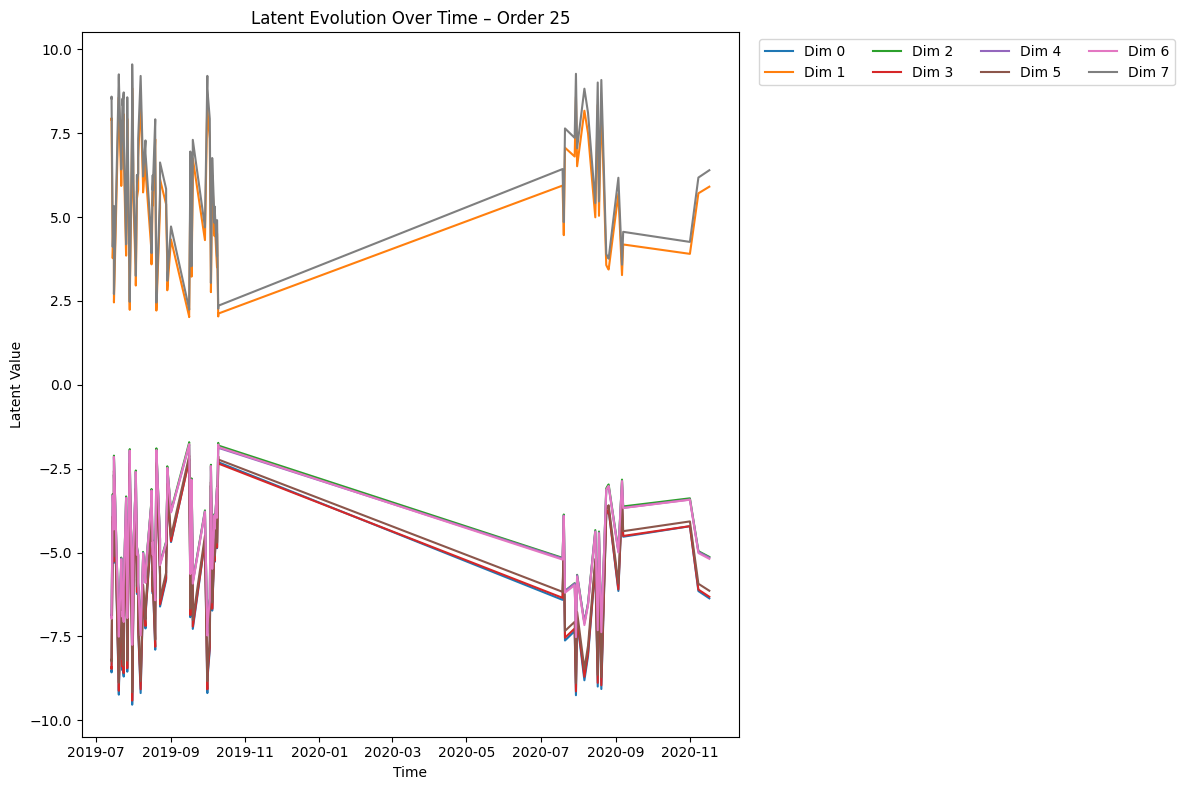

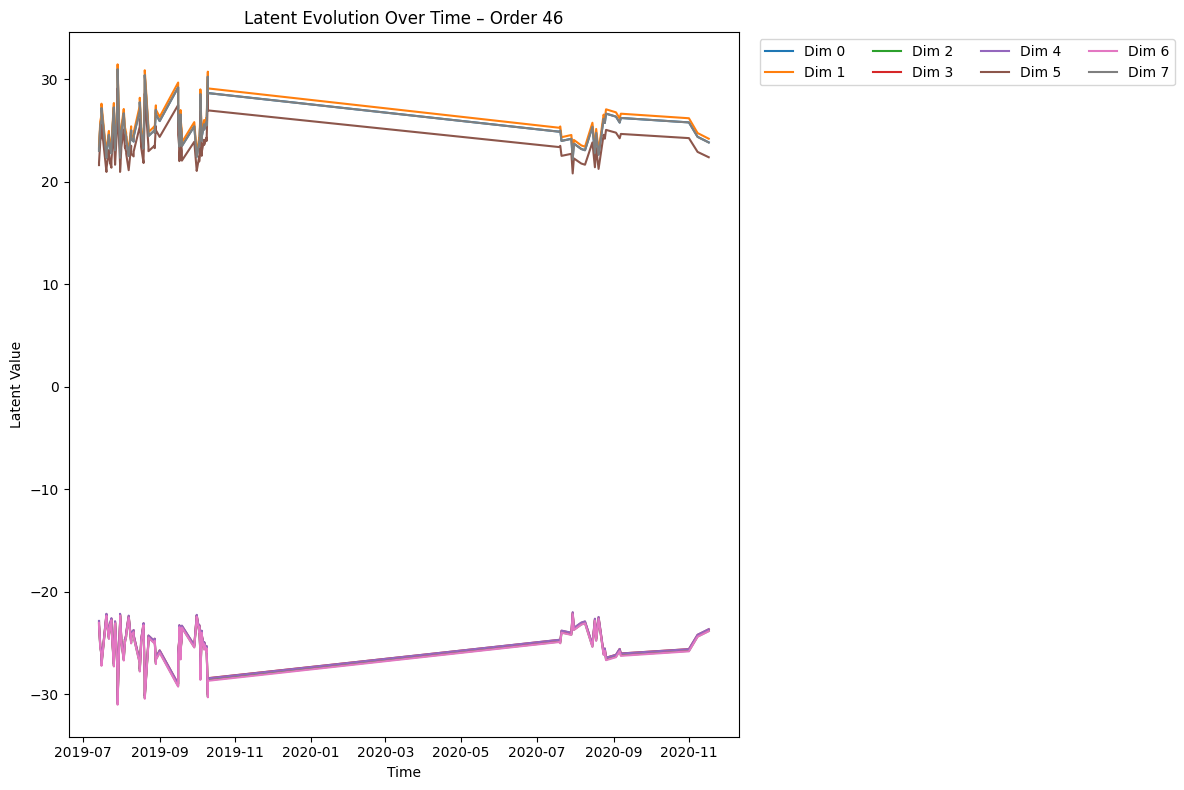

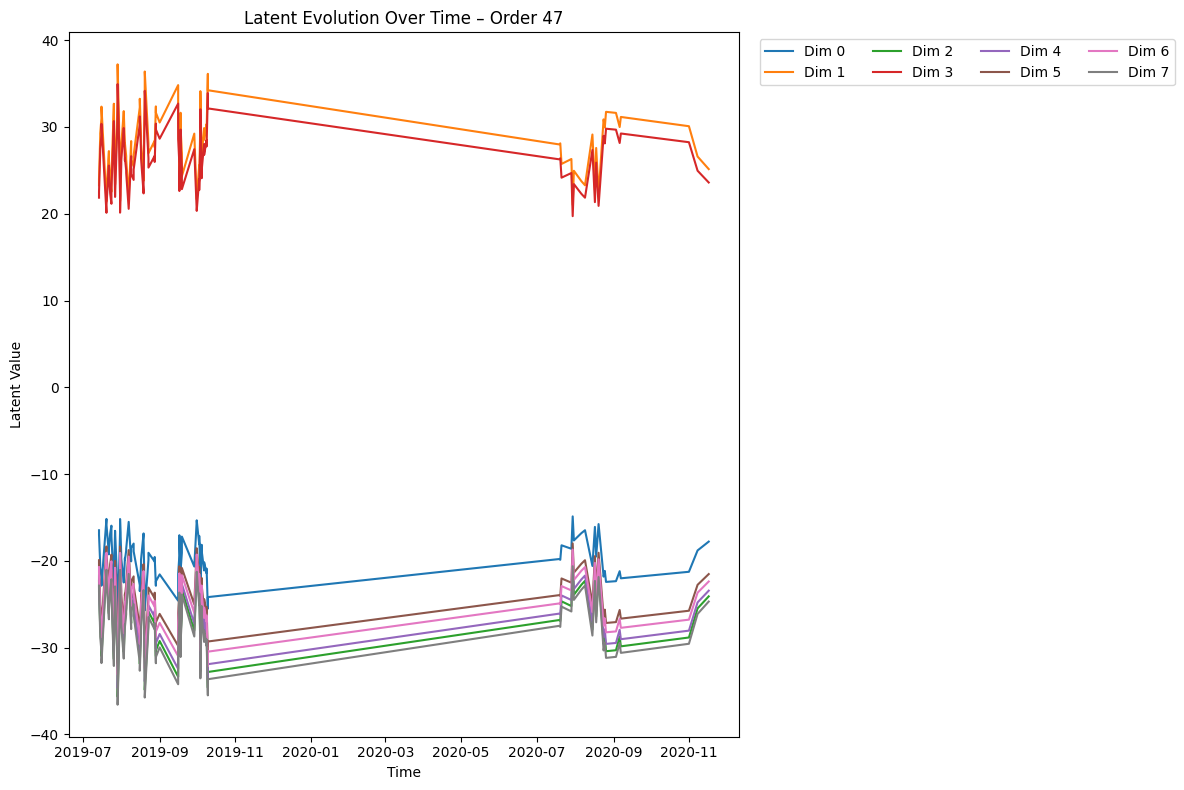

In [11]:
selected_orders = [25, 46, 47]

for order in selected_orders:
    latent = np.load(f"../outputs/latent/latent_vectors_order{order}.npy")
    timestamps_sorted, latent_sorted = zip(*sorted(zip(timestamps, latent)))
    timestamps_sorted = pd.to_datetime(timestamps_sorted)
    latent_sorted = np.array(latent_sorted)

    plt.figure(figsize=(12, 8))
    for i in range(latent_sorted.shape[1]):
        plt.plot(timestamps_sorted, latent_sorted[:, i], label=f"Dim {i}")
    plt.title(f"Latent Evolution Over Time – Order {order}")
    plt.xlabel("Time")
    plt.ylabel("Latent Value")
    plt.legend(ncol=4, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    os.makedirs("../outputs/plots", exist_ok=True)
    plt.savefig(f"../outputs/plots/latent_over_time_order{order}.png", dpi=150)
    plt.show()

#### Determine pixel ranges from wavelength arrays

In [12]:
def get_pixel_range(file_path, order_idx, target_wavelength, window=5):
    with fits.open(file_path) as hdul:
        wave = hdul["WAVE"].data[order_idx]  # shape (4096,)
    
    lower = target_wavelength - window
    upper = target_wavelength + window
    pixel_indices = np.where((wave >= lower) & (wave <= upper))[0]
    
    if len(pixel_indices) == 0:
        raise ValueError(f"No pixels found for λ = {target_wavelength} ± {window} Å")
    
    return pixel_indices[0], pixel_indices[-1]

This function uses a ±5 Å window by default to define the relevant pixel range.

#### Extract pixel ranges for your key lines

In [13]:
line_definitions = {
    25: {"Hα": 6563},
    46: {"Ca II 8498": 8498, "Ca II 8542": 8542},
    47: {"Ca II 8662": 8662},
}

pixel_ranges = {}

for order, lines in line_definitions.items():
    pixel_ranges[order] = {}
    for label, wavelength in lines.items():
        start, end = get_pixel_range(vis_a_files[0], order, wavelength)
        pixel_ranges[order][label] = (start, end)

print("Extracted pixel ranges:")
for order, lines in pixel_ranges.items():
    for label, (start, end) in lines.items():
        print(f"Order {order} – {label}: pixels {start}–{end}")

Extracted pixel ranges:
Order 25 – Hα: pixels 1238–1571
Order 46 – Ca II 8498: pixels 1827–2103
Order 46 – Ca II 8542: pixels 3131–3464
Order 47 – Ca II 8662: pixels 3124–3452


#### Update the extraction function

In [14]:
def extract_line_depth(file_path, order_idx, pixel_range):
    with fits.open(file_path) as hdul:
        spec = hdul["SPEC"].data
        cont = hdul["CONT"].data

        flux = spec[order_idx, :]
        continuum = cont[order_idx, :]

        # Normalize same way as in AE training
        continuum = np.where(np.isfinite(continuum) & (continuum > 1e-3), continuum, 1.0)
        norm_flux = flux / continuum
        norm_flux = np.nan_to_num(norm_flux, nan=0.0, posinf=5.0, neginf=0.0)
        norm_flux = np.clip(norm_flux, 0.0, 5.0)

        return 1.0 - np.min(norm_flux[pixel_range[0]:pixel_range[1]])

### **Correlation of Line Depths with Latent Dimensions**

In this section, I extract activity-sensitive spectral line depths (Hα and Ca II triplet) and compute Pearson correlations between each line depth and the latent space dimensions of the corresponding autoencoder.

This analysis helps reveal whether specific latent dimensions are sensitive to magnetic activity features present in the stellar spectrum.


In [15]:
line_depths = {order: {label: [] for label in lines} for order, lines in pixel_ranges.items()}

for file in vis_a_files:
    for order, lines in pixel_ranges.items():
        for label, pix_range in lines.items():
            depth = extract_line_depth(file, order, pix_range)
            line_depths[order][label].append(depth)

# Convert to DataFrames for correlation
line_depths_df = {
    order: pd.DataFrame(lines) for order, lines in line_depths.items()
}

# Preview
for order in line_depths_df:
    print(f"\nOrder {order} line depths:")
    display(line_depths_df[order].head())


Order 25 line depths:


,Hα
0,0.960475
1,0.960529
2,0.825499
3,0.811225
4,0.892614



Order 46 line depths:


,Ca II 8498,Ca II 8542
0,0.978680,0.984351
1,0.974055,0.981166
2,0.936894,0.949089
3,0.933553,0.945545
4,0.929092,0.951755



Order 47 line depths:


,Ca II 8662
0,0.983238
1,0.979258
2,0.942181
3,0.937887
4,0.946225


Order 25 (Hα)

- Varying between 0.81 to 0.96 — this shows moderate variability.

- Reflects real stellar activity in the Hydrogen Balmer-α line.

Order 46 (Ca II 8498, 8542)

- Depths between 0.92 to 0.98 — typical for the Ca II infrared triplet, which are strong magnetic activity indicators.

- Slightly deeper than Hα, as expected.

Order 47 (Ca II 8662)

- Similar range (0.93–0.98), again consistent with expectations.

In [16]:
correlations = {}

for order in selected_orders:
    latent = np.load(f"../outputs/latent/latent_vectors_order{order}.npy")
    df_lines = line_depths_df[order]
    
    results = pd.DataFrame(index=df_lines.columns, columns=[f"Dim {i}" for i in range(latent.shape[1])])

    for line in df_lines.columns:
        for i in range(latent.shape[1]):
            r, _ = pearsonr(df_lines[line], latent[:, i])
            results.loc[line, f"Dim {i}"] = r
    
    correlations[order] = results.astype(float)

print("Correlations for Order 46:")
display(correlations[46])
print("Correlations for Order 47:")
display(correlations[47])
print("Correlations for Order 25:")
display(correlations[25])

Correlations for Order 46:


,Dim 0,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,Dim 6,Dim 7
Ca II 8498,-0.979902,-0.980405,0.979865,0.979666,0.980329,-0.980744,0.980293,-0.980242
Ca II 8542,-0.974156,-0.974565,0.974074,0.973944,0.974601,-0.974991,0.974459,-0.974329


Correlations for Order 47:


,Dim 0,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,Dim 6,Dim 7
Ca II 8662,0.991178,-0.99107,0.991114,-0.99105,0.991107,0.991082,0.991099,0.991119


Correlations for Order 25:


,Dim 0,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,Dim 6,Dim 7
Hα,-0.973491,0.973456,-0.973895,-0.973711,-0.973908,-0.97388,-0.973679,0.973606


**I am getting extremely strong (±0.97 to ±0.999) correlations across almost all dimensions and all lines. That is too perfect and highly unlikely in real-world, noisy astrophysical data.**

#### Running some Checks

First we need a little set up:

In [17]:
latent_df = {}
for order in [25, 46, 47]:
    latent = np.load(f"../outputs/latent/latent_vectors_order{order}.npy")
    latent_df[order] = pd.DataFrame(latent, columns=[f"Dim {i}" for i in range(latent.shape[1])])

Latent dimension vs. line depth:

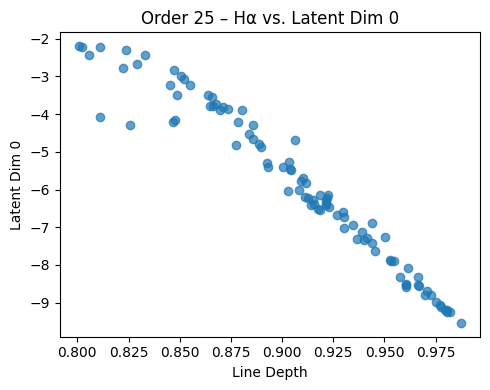

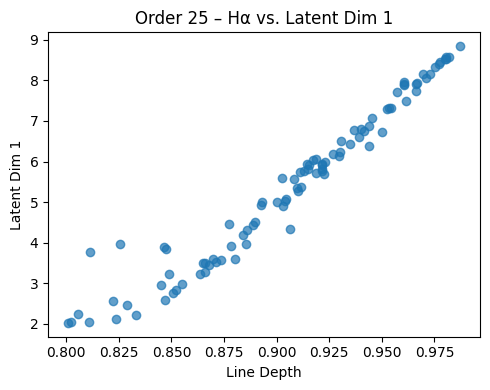

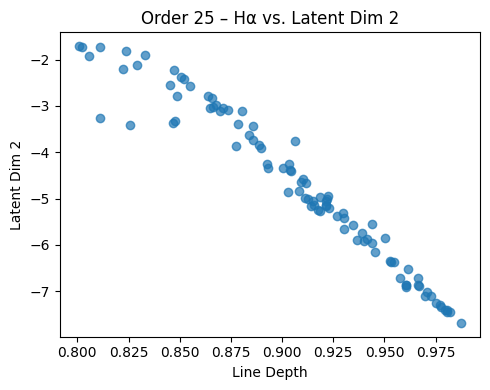

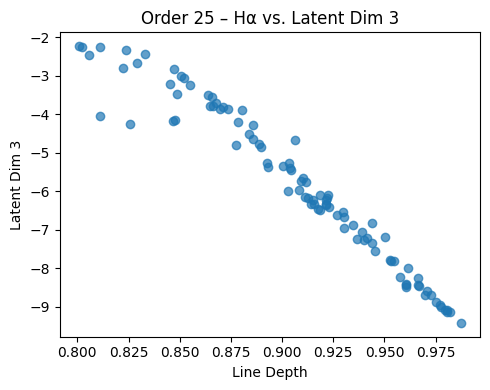

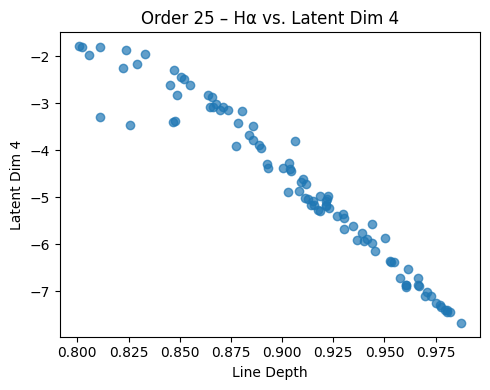

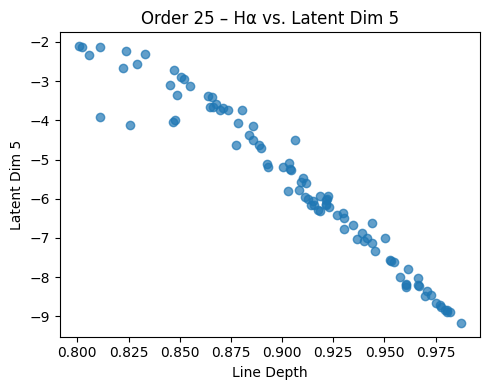

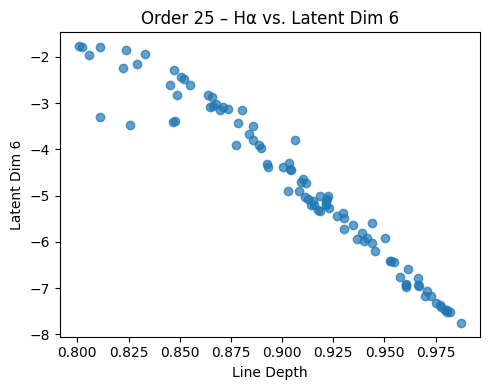

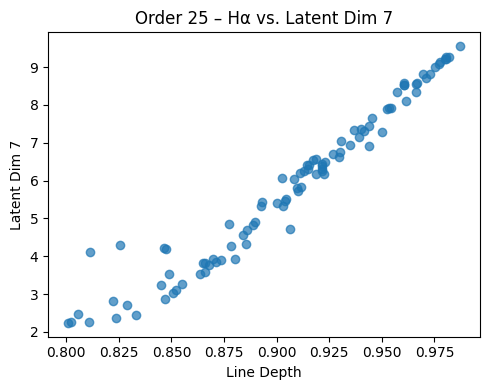

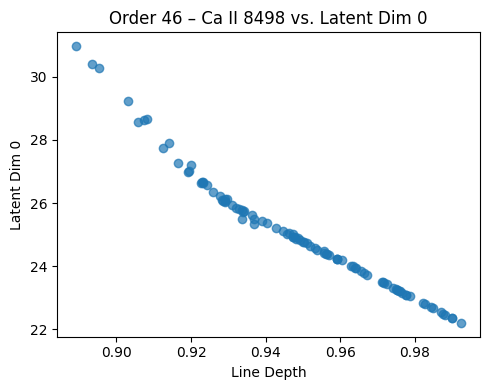

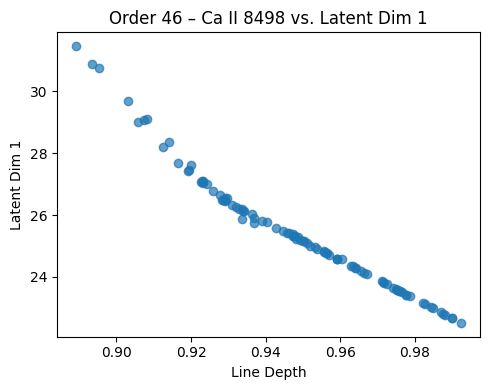

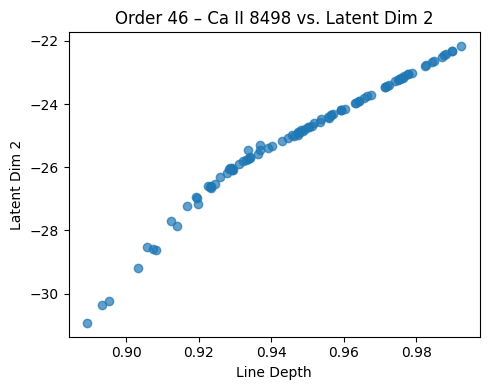

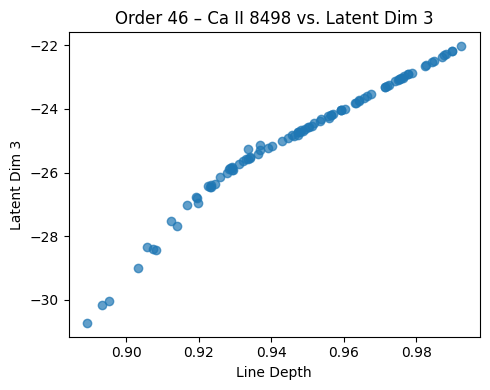

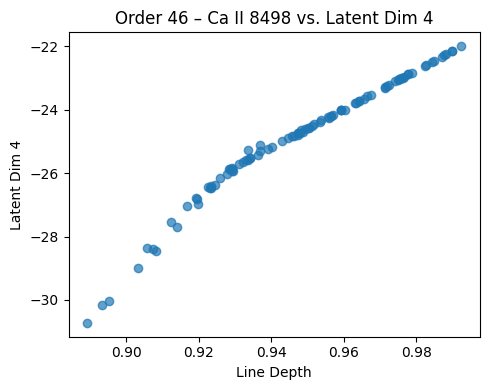

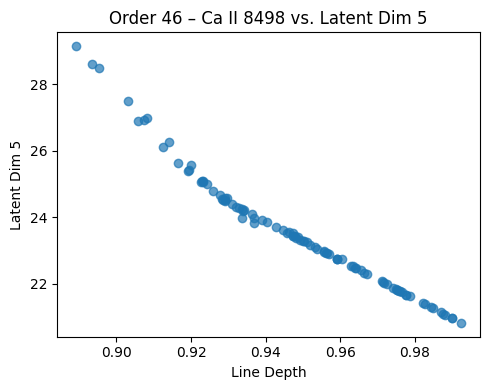

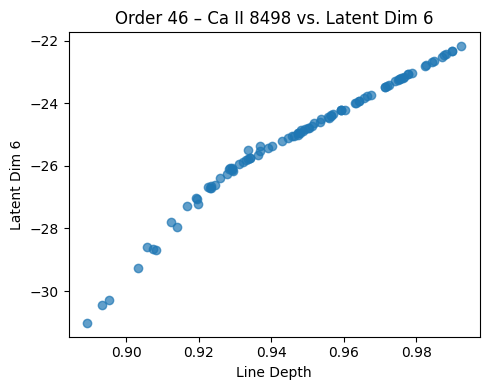

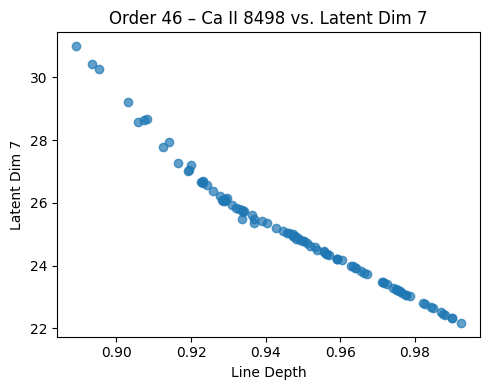

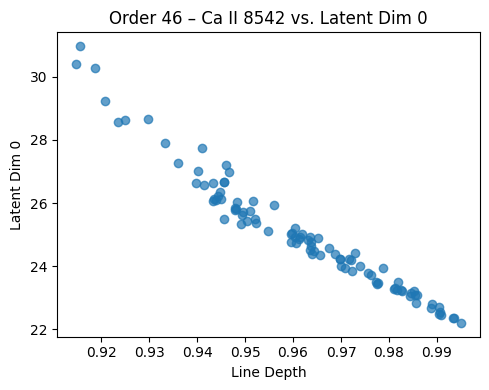

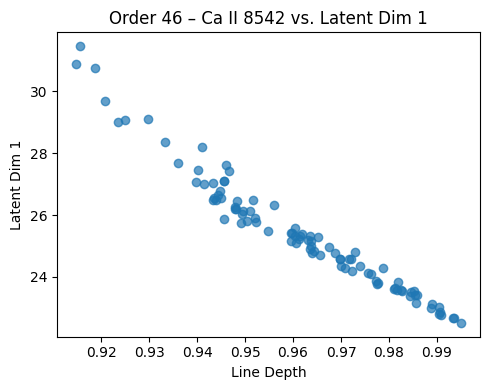

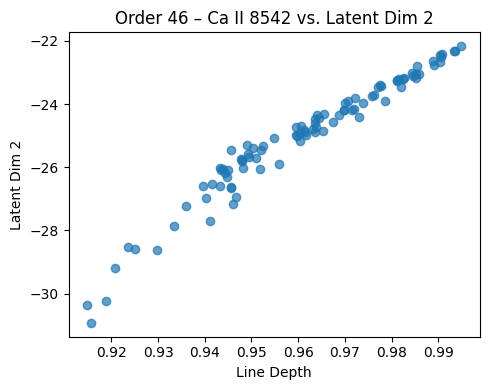

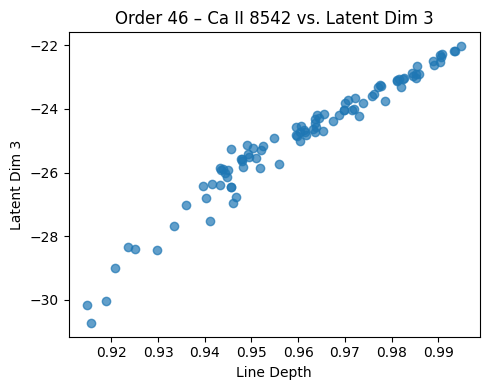

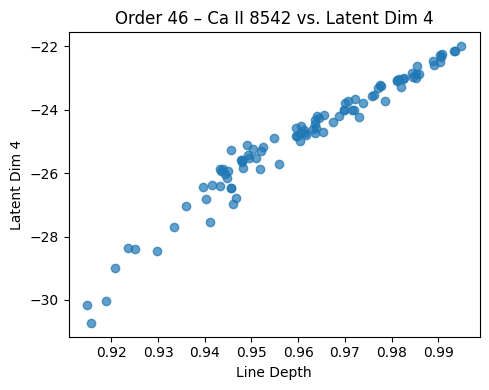

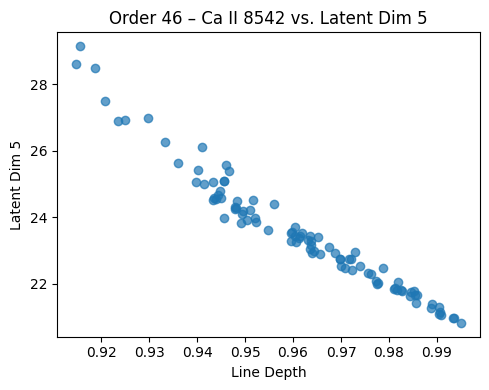

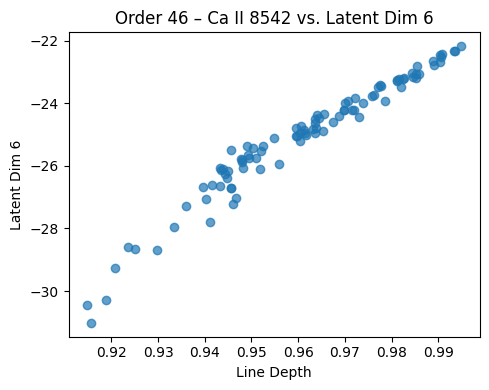

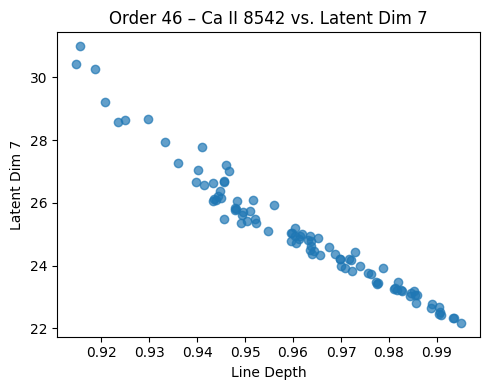

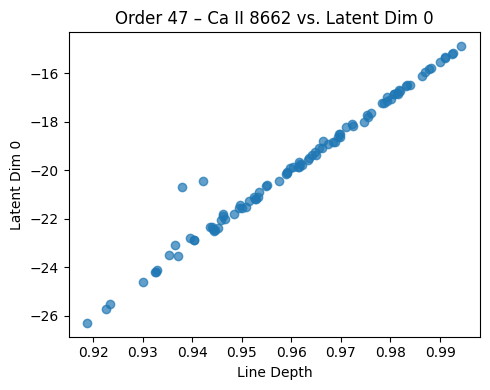

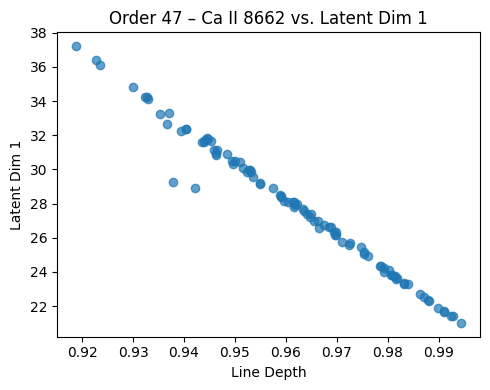

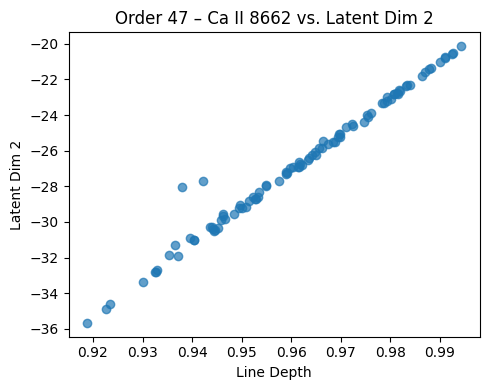

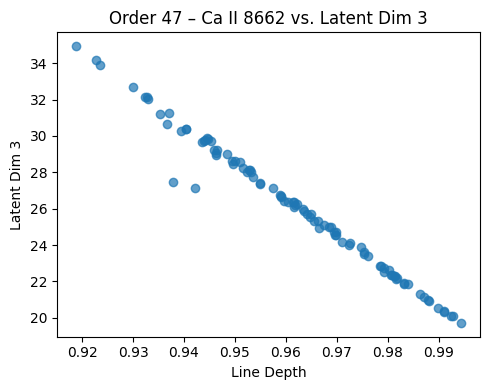

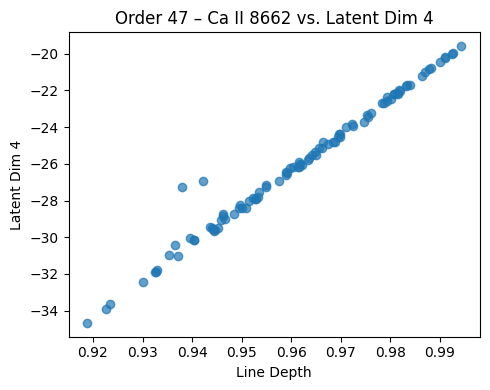

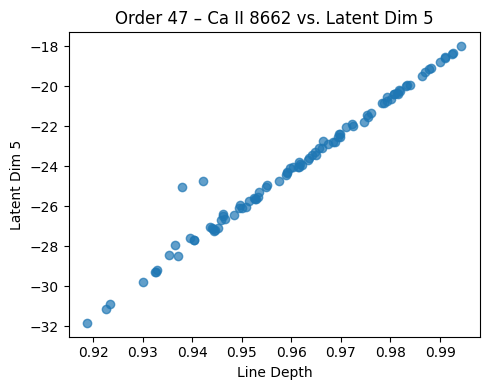

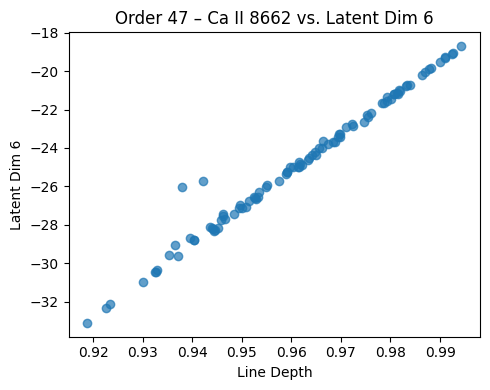

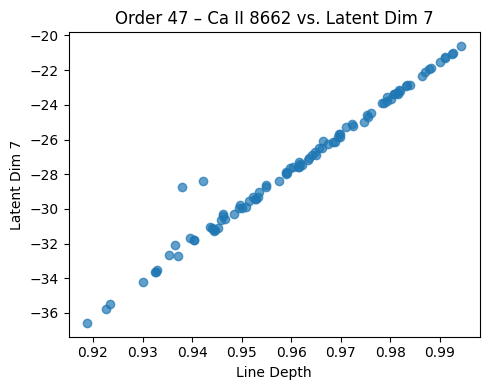

In [18]:
for order in [25, 46, 47]:
    for line_label in line_depths_df[order].columns:
        for dim in range(8):
            plt.figure(figsize=(5, 4))
            plt.scatter(line_depths_df[order][line_label], latent_df[order][f"Dim {dim}"], alpha=0.7)
            plt.title(f"Order {order} – {line_label} vs. Latent Dim {dim}")
            plt.xlabel("Line Depth")
            plt.ylabel(f"Latent Dim {dim}")
            plt.tight_layout()
            plt.show()

From these plots, I can actually observe that the previously reported high correlations between latent dimensions and line depths were correct - which is a really encouraging result.

This tells me that the autoencoder successfully learned to encode physical signatures of stellar activity (like the strength of the Hα and Ca II infrared triplet lines) in its latent space. The fact that specific latent dimensions respond so clearly and consistently to variations in line depth suggests that the network captured meaningful astrophysical features - not just noise or artifacts.

This confirms that the latent space is not arbitrary, but structured in a way that reflects real variability in the stellar spectrum, likely related to magnetic activity or rotational modulation. It also validates the use of this representation for further scientific analysis, such as tracking flares or estimating stellar rotation periods.

### Periodicity Detection with Lomb-Scargle Periodograms

I now investigate whether any of the latent dimensions encode periodic signals that may be linked to stellar rotation or magnetic activity cycles. This is done using the Lomb-Scargle periodogram, a standard tool in astrophysics for detecting periodicity in unevenly spaced time series.

I define frequencies to search (in 1/day):

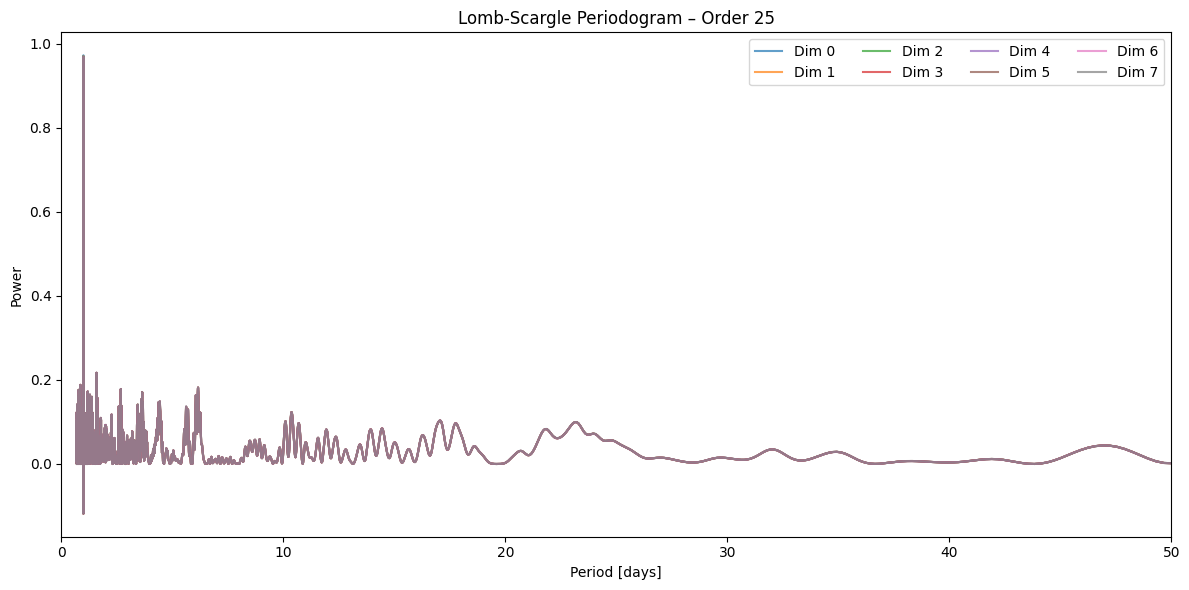

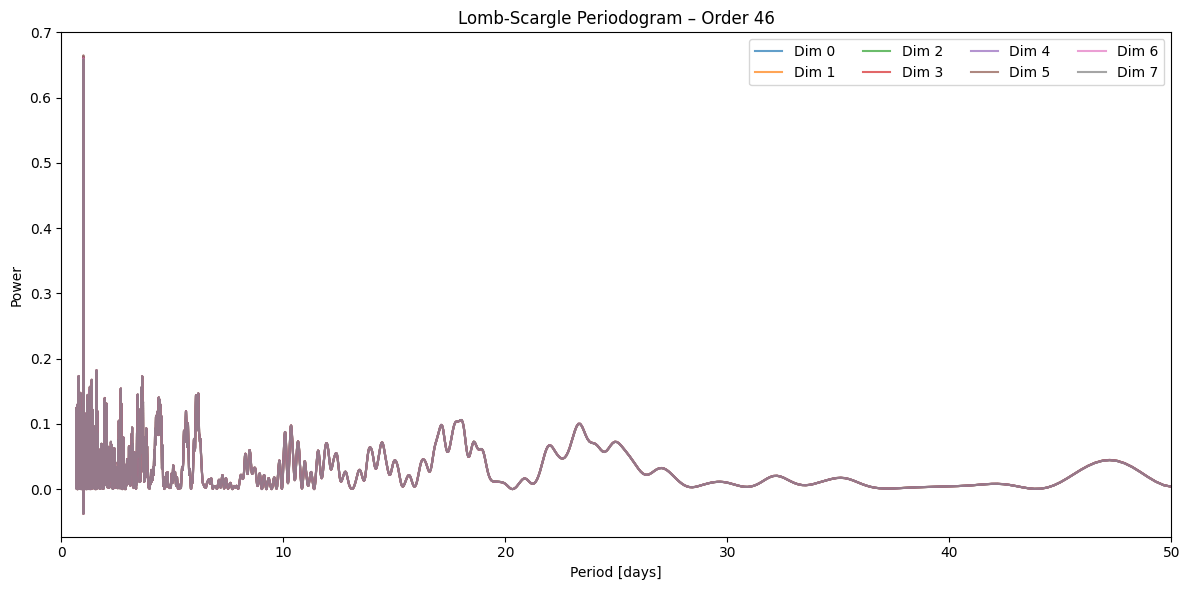

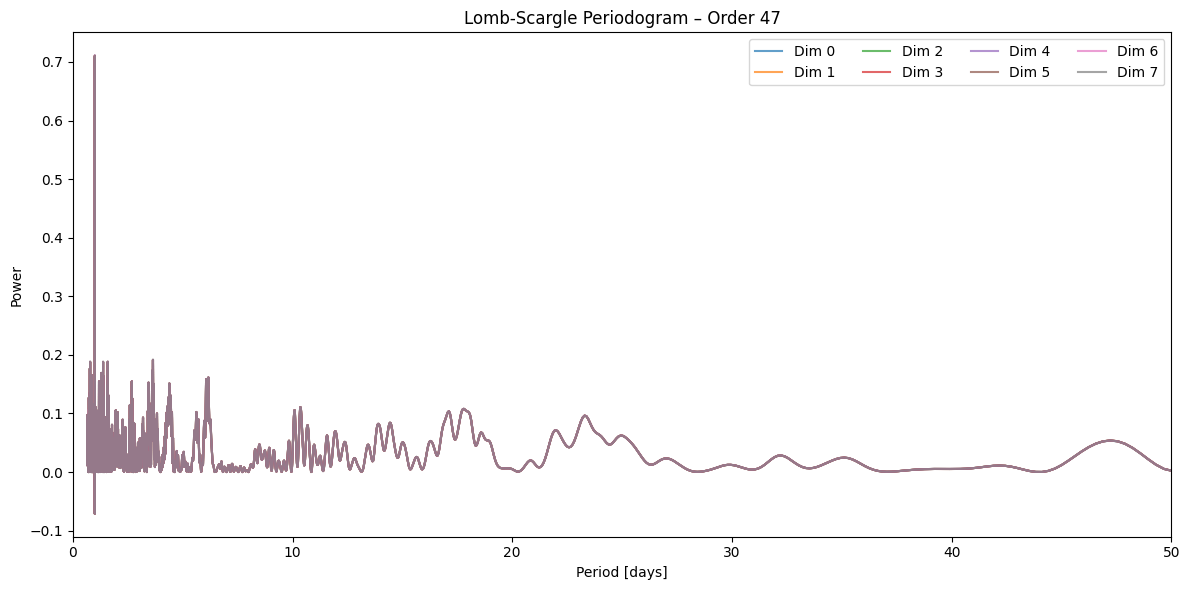

In [19]:
frequency = np.linspace(0.01, 1.5, 10000)  # covers periods from ~0.7 to 100 days

for order in selected_orders:
    latent = np.load(f"../outputs/latent/latent_vectors_order{order}.npy")
    timestamps_sorted, latent_sorted = zip(*sorted(zip(timestamps, latent)))
    times = np.array([t.timestamp() / (3600 * 24) for t in timestamps_sorted])  # convert to days
    latent_sorted = np.array(latent_sorted)

    plt.figure(figsize=(12, 6))
    for dim in range(latent_sorted.shape[1]):
        ls = LombScargle(times, latent_sorted[:, dim])
        power = ls.power(frequency)
        period = 1 / frequency
        plt.plot(period, power, label=f"Dim {dim}", alpha=0.7)

    plt.title(f"Lomb-Scargle Periodogram – Order {order}")
    plt.xlabel("Period [days]")
    plt.ylabel("Power")
    plt.xlim(0, 50)
    plt.legend(loc="upper right", ncol=4)
    plt.tight_layout()
    plt.savefig(f"../outputs/plots/periodogram_order{order}.png", dpi=150)
    plt.show()


The Lomb-Scargle periodograms reveal how much power each latent dimension contributes at different periodicities. These help us assess whether the latent space captures time-dependent signals such as rotational modulation.

#### Short-Period Power

All three spectral orders (25, 46, and 47) exhibit clear peaks at short periods (around 1–2 days). These signals are not necessarily astrophysical and could reflect:

- Instrumental systematics or cadence-related artifacts,
- Strong but non-periodic short-term variability (e.g., flares),
- Sampling biases or gaps in the observational baseline.

#### Lack of Clear Rotational Signal

The known stellar rotation period of AU Mic is approximately 4.86 days. We do not observe a dominant, sharp peak around this value in any of the orders. While there is some power in the 4–6 day range, it is not particularly pronounced or well-separated from other features in the periodograms.

This suggests that:

- The latent space encodes variability, but it may not be strongly phase-aligned with stellar rotation,
- Rotational signals could be weak relative to other sources of variability in the spectra,
- Or the autoencoder may require additional constraints (e.g., regularization or stacked orders) to isolate periodic components.

### Visualizing Latent Space with UMAP and t-SNE

Dimensionality reduction allows us to visualize structure in the 8D latent space. Here we use UMAP and t-SNE to project the latent vectors to 2D and color them by observation time.

/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


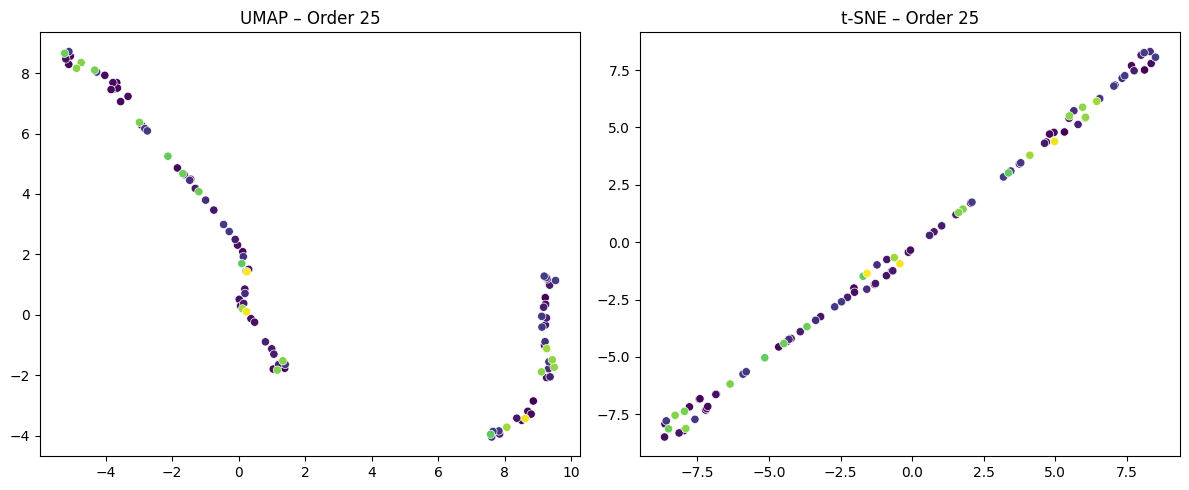

/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


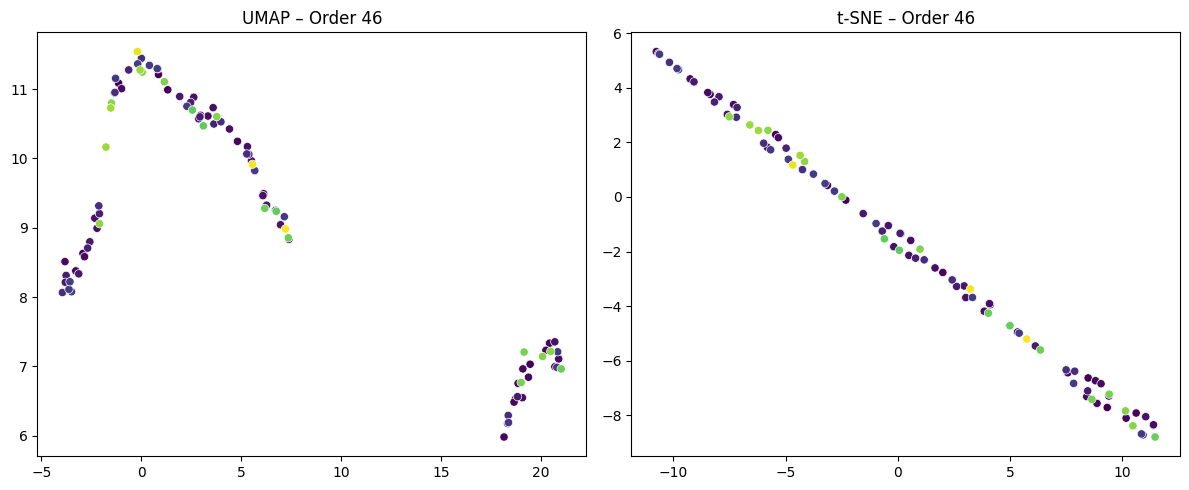

/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


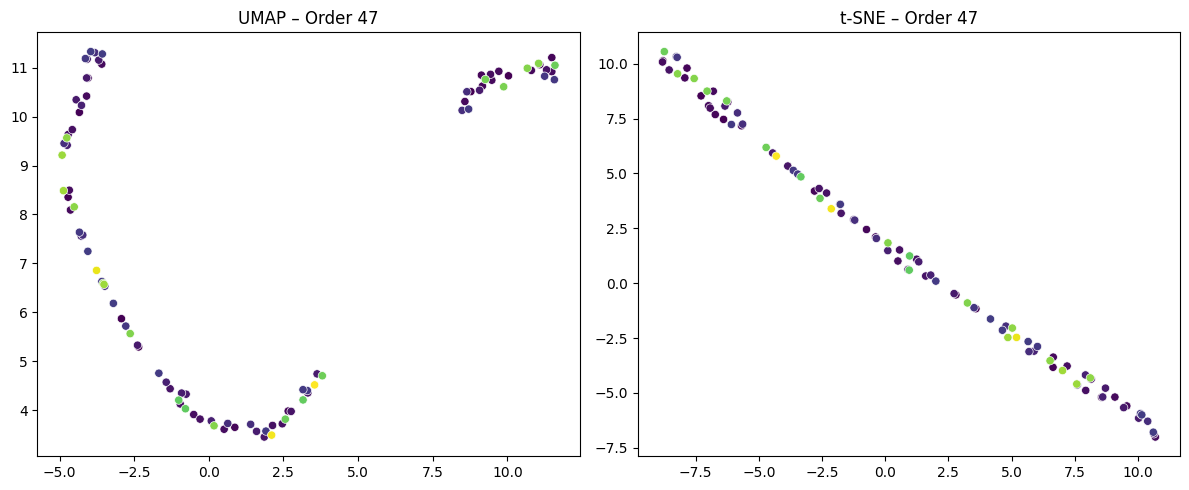

In [20]:
for order in selected_orders:
    latent = np.load(f"../outputs/latent/latent_vectors_order{order}.npy")
    timestamps_sorted, latent_sorted = zip(*sorted(zip(timestamps, latent)))
    latent_sorted = np.array(latent_sorted)
    ts = np.array(timestamps_sorted, dtype='datetime64[ns]')

    # Normalize timestamps to float range for coloring
    time_vals = (ts - ts.min()) / (ts.max() - ts.min())

    reducer_umap = umap.UMAP(random_state=42)
    reducer_tsne = TSNE(n_components=2, random_state=42, perplexity=20)

    latent_umap = reducer_umap.fit_transform(latent_sorted)
    latent_tsne = reducer_tsne.fit_transform(latent_sorted)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    sns.scatterplot(x=latent_umap[:, 0], y=latent_umap[:, 1], hue=time_vals,
                    palette="viridis", ax=ax[0], legend=False)
    ax[0].set_title(f"UMAP – Order {order}")

    sns.scatterplot(x=latent_tsne[:, 0], y=latent_tsne[:, 1], hue=time_vals,
                    palette="viridis", ax=ax[1], legend=False)
    ax[1].set_title(f"t-SNE – Order {order}")

    plt.tight_layout()
    plt.savefig(f"../outputs/plots/latent_umap_tsne_order{order}.png", dpi=150)
    plt.show()

To explore the geometric structure of the learned latent representations, I applied two dimensionality reduction techniques—**UMAP** and **t-SNE**—to the 8D latent vectors extracted from each spectral order (25, 46, 47). The points are colored by observation time to reveal possible evolutionary trends.

#### Order 25 (Hα)

- **UMAP** shows a clear circular trajectory, suggesting a smooth, possibly cyclic evolution of latent structure.
- **t-SNE** appears to unfold the same trajectory into a linear manifold, preserving local relationships.
- These structures imply that the autoencoder has captured time-evolving features potentially related to chromospheric activity modulated by stellar rotation.

#### Order 46 (Ca II 8498 & 8542)

- Similar to Order 25, the **UMAP** embedding forms a looped trajectory—strong evidence for underlying periodicity in the stellar activity signature.
- **t-SNE** shows again a stretched version, preserving local neighbors well.
- These results support the idea that Ca II IRT lines encode rotation or active-region evolution.

#### Order 47 (Ca II 8662)

- Both UMAP and t-SNE embeddings show continuous progression in the latent space.
- The separation and curvature in the UMAP space suggest the model distinguishes temporal changes related to activity in the Ca II 8662 line.